# DAF-16: The Metric That Matches Asha's Decision — Walk-Forward Evaluation

## The story

Asha is the school coordinator. Every evening at 18:00 she decides whether 600 children go outside tomorrow. The model gives her a number, and she turns it into one of two actions: **outside** or **indoors**.

So far we graded the model with MAE, the average size of its mistakes. Asha does not feel an average. She feels two very different evenings:

- **A false alarm.** The model says Poor, the air is fine. The children stay in for a day. Annoying, but nobody is hurt.
- **A missed Poor day.** The model says fine, the air is Poor. 600 children breathe it for a whole afternoon. This is the one that ends up in a parent's complaint.

MAE counts these two mistakes the same. A model can have a nice MAE and still miss the days that matter.

There is a second problem. Every score so far came from **one cut date**, 2026-03-01. The test period was spring and summer, only 17 Poor days, and Delhi's real danger season was in the training half. One exam on one kind of weather does not tell Asha how the model behaves in November.

DAF-16 fixes both: it judges the model on **Asha's decision**, and it tests it **month after month** the way it would really be used.

## What this ticket is about

Two changes to how we score a model. The model itself does not change.

```text
Before                                    After
one cut date, one test period             many monthly exams, each on unseen days
MAE as the headline                       recall and false alarms as the headline
"how far off on average?"                 "did Asha warn on the Poor days?"
```

Backend analogy: MAE is like reporting average latency. Recall on Poor days is like reporting how many real outages your alert caught. Average latency can look healthy while the alert system misses the one outage that mattered. Walk-forward evaluation is like replaying last year's traffic day by day against a system that only knew the past, instead of load-testing it once.

## The decision view

Every forecast becomes Asha's action with the CPCB table (D-001): a forecast of **91 or above** means warn, anything below means all-clear. Put the forecast against what really happened and every day lands in one of four boxes:

| | Actually Poor or worse | Actually below 91 |
|---|---|---|
| **Forecast Poor or worse** | correct warning | false alarm |
| **Forecast below 91** | **missed Poor day — the dangerous one** | correct all-clear |

Two numbers come out of this table:

- **Recall** = correct warnings ÷ all actual Poor days. *Of the days I should have warned on, how many did I?*
- **Precision** = correct warnings ÷ all warnings. *When I warned, how often was I right?*

Recall protects the children. Precision protects Asha's credibility: a model that cries wolf every week stops being believed.

## Walk-forward evaluation

Pick a start date. Train on everything **before** it, predict the next month, then move forward one month, retrain, and repeat.

```text
step 1   train |■■■■■■■■■■■■|  test |□□□□|
step 2   train |■■■■■■■■■■■■■■■■|  test |□□□□|
step 3   train |■■■■■■■■■■■■■■■■■■■■|  test |□□□□|
                          time  ───────────────────────►
```

The training window grows each step (an *expanding window*), and every month is scored by a model that never saw it. This is exactly how the service will live: each month, retrain on all the history, forecast the next days.

What it tells us that one cut date cannot: how the model does in **each season**, including winter, and how much the score wobbles from month to month.

**An honest limit.** The data starts in February 2025, so there is only **one winter** (Nov 2025 to Feb 2026). When walk-forward reaches that winter, the model has never seen a winter. That is a realistic, hard test, and we will say so when we read the results.

## Moving the warning line

If the model misses Poor days, it can warn earlier: instead of warning when the forecast reaches 91, warn at 80. Recall goes up, and so do false alarms.

```text
warn at 100  →  few false alarms, more missed Poor days
warn at  91  →  the official line
warn at  70  →  few missed Poor days, many false alarms
```

This is a **product decision**, not a modelling trick: it is Asha choosing how many cancelled outdoor days she will accept to avoid one missed Poor day. If we move the line, it is recorded as **D-007**.

The trap: maximising recall alone. A model that always says "indoors" has perfect recall and is useless. We always read recall **with** false alarms per month.

## The three models

We compare the best model of each kind from the earlier tickets, all using the same four features.

| Model | From | Why it is here |
|---|---|---|
| Persistence | DAF-06 | The floor. "Tomorrow = today so far." Any model must beat this |
| Ridge, `daf14_selected` | DAF-14 | Best model so far: MAE 15.588, caught 12 of 17 Poor days |
| Best tree model | DAF-15 | Random forest had the best MAE of the three trees (18.900). The decision tree caught more Poor days but with MAE 25.1 |

Features: `pm25_until_17`, `mean_3`, `mean_7`, `mean_14`. Persistence uses only `pm25_until_17`.

## Rules for this ticket

- **No future inside the loop.** At every step the scaler, the feature selection and the model are fitted on the training window only. Features are built from past days, so a row never contains information from after its own 18:00.
- **Settings are fixed before the loop.** No hyper-parameter is chosen by looking at walk-forward scores. DAF-17 tunes. Here we only evaluate.
- **Warning line 91 first.** Every number is reported at the official line before we explore moving it.
- Every experiment-log row is marked `walk-forward`, because these scores are **not comparable** with the single-cut rows from earlier tickets: different test days, different method.

### The rules, as a picture

![The four rules of DAF-16](figures/16_rules.png)

Rule 1 is the one that matters most. Picture Asha on 30 November, testing December. She may only use what she knew that day. If the scaler is computed on all rows, it has already "seen" December, and the test stops being a test.

## The plan, one step at a time

1. Write one scoring function: MAE, recall, precision and the confusion matrix for any predictions.
2. Rebuild the feature table, and choose the walk-forward start date.
3. Write the walk-forward loop: monthly steps, expanding window, retrain each step.
4. Run it for persistence, Ridge and the random forest. Report metrics per month and overall, with the confusion matrix for the best model.
5. Plot recall per month for the three.
6. Try warning lines from 70 to 100. Plot recall and false alarms against the line.
7. Decide whether to move the line, and record D-007 if we do.
8. Add the `walk-forward` rows to `reports/experiments.csv`.

We will do one step at a time. Step 1 comes next.

### The plan, as a picture

![The eight steps of DAF-16](figures/16_plan.png)

Read it left to right, top to bottom. Steps 1 to 4 build and run the exam. Steps 5 to 7 read the results and make Asha's decision. Step 8 writes the evidence down. The two blue cards are where the real thinking happens.

# Step 1 — One scoring function for Asha's decision

## 🎬 How we got here

Every score so far was an MAE, plus a recall that we worked out by hand, in a slightly different way, inside each notebook. In DAF-15 the `score` function lived inside Step 2 and only returned three numbers.

Asha now wants to judge models on **her decision**. Walk-forward will score a model twelve times, once per month, for three models. Doing that by copy-pasting scoring code would be slow, and one typo would quietly change a result.

## 😖 The problem

MAE treats every mistake by its **size**. Asha cares about its **direction**. Here are two days from a small example we will build in this step:

```text
            what really happened    what the model said    error     what it meant for Asha
Day 3       Poor (95)               90 -> "fine"            only 5    MISSED Poor day. Children outside in bad air.
Day 2       fine (60)               95 -> "Poor"            35        false alarm. Children stay in for a day.
```

The dangerous day has the **small** error (5). The harmless day has the **big** error (35). An average of errors cannot tell them apart. We need to count the two kinds of mistake separately.

## 💡 The idea

Write **one function** that takes the real PM2.5 values and the forecasts, and returns everything Asha needs in one go. Every later step calls it and nothing else.

```text
actual PM2.5  ──┐                              ┌─► MAE          (size of mistakes)
                ├─► score_forecasts(...) ──────┼─► recall       (Poor days caught)
forecast PM2.5 ─┘                              ├─► precision    (warnings that were right)
                                               └─► 4 counts     (the confusion matrix)
```

The four counts come from putting each day in one box:

```text
                          REALLY Poor (>= 91)        REALLY fine (< 91)
  Model said Poor    │   TP  correct warning     │   FP  false alarm          │
  Model said fine    │   FN  MISSED Poor day     │   TN  correct all-clear    │
```

Backend analogy: this is your alerting dashboard. TP is an outage that paged you. FN is an outage that **did not** page you. FP is a page for no outage. MAE is like "average CPU", useful but not what wakes anyone up.

## 🔍 What this actually is

- **Two lines, not one.** `poor_line` (default 91) decides what **really** counts as a Poor day. `warn_at` (default 91) decides when the model **warns**. For now they are equal. In Step 6 we move only `warn_at`, and the truth stays fixed.
- **Recall and precision can be undefined.** A month with no Poor day has nothing to catch, so recall would be 0 ÷ 0. The function returns `NaN` (not a number) instead of a fake 0 or 1. A month with no warnings has the same problem for precision. Walk-forward will hit both cases, so this matters.
- **Counts, not only ratios.** With about 17 Poor days, one day moves recall by 0.06. The counts are always returned next to the ratios, so nobody over-reads a small difference.

### 🤔 Before you run the code

In the 8-day example, the model warns on 5 days and there are 4 really Poor days. Can you guess how many of the 4 it caught? Then read the result.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, mean_absolute_error


def score_forecasts(actual, predicted, poor_line=91, warn_at=91):
    """Score forecasts the way Asha uses them: size of error, and right / wrong warnings."""
    # --- 1. Plain arrays of numbers, so lists, Series and arrays all work ---------
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    assert actual.shape == predicted.shape, "actual and predicted must have the same length"

    # --- 2. Turn numbers into yes / no answers --------------------------------------
    really_poor = actual >= poor_line      # what happened: was it a Poor day?
    warned = predicted >= warn_at          # what the model said: did it warn?

    # --- 3. Count each of the four boxes ----------------------------------------------
    tp = int((really_poor & warned).sum())     # Poor day, model warned
    fn = int((really_poor & ~warned).sum())    # Poor day, model stayed quiet  <- dangerous
    fp = int((~really_poor & warned).sum())    # fine day, model warned
    tn = int((~really_poor & ~warned).sum())   # fine day, model stayed quiet

    # --- 4. Ratios. Dividing by zero means "undefined", so return NaN ---------------
    n_poor = tp + fn                           # all really Poor days
    n_warnings = tp + fp                       # all warnings
    recall = tp / n_poor if n_poor else np.nan
    precision = tp / n_warnings if n_warnings else np.nan

    return {
        "mae": mean_absolute_error(actual, predicted),
        "recall": recall,
        "precision": precision,
        "tp": tp, "fn": fn, "fp": fp, "tn": tn,
        "n_days": len(actual), "n_poor": n_poor,
    }


def confusion_table(result):
    """The four counts as the 2x2 table Asha reads."""
    return pd.DataFrame(
        [[result["tp"], result["fp"]], [result["fn"], result["tn"]]],
        index=["Model said Poor", "Model said fine"],
        columns=["Really Poor", "Really fine"],
    )

### What this code does

| Part | What it does |
|---|---|
| `score_forecasts(actual, predicted, ...)` | The one function every later step will call |
| `really_poor`, `warned` | Two lists of True / False, one entry per day. Everything else is counting them |
| `&` and `~` | `&` means "and". `~` means "not". `really_poor & ~warned` reads "really Poor and the model did not warn" |
| `nan` when dividing by zero | Keeps "no Poor days this month" different from "caught none of them" |
| `confusion_table(result)` | Shows the four counts in the same 2x2 layout as the picture above |

Nothing has run on real data yet. Next we try it on 8 days small enough to check by hand.

In [2]:
# --- An 8-day example small enough to check with a pencil ---------------------------
days = pd.DataFrame(
    {
        "actual":   [45, 60, 95, 120, 70, 100, 85, 150],   # the real PM2.5 of each day
        "forecast": [50, 95, 90, 130, 60, 105, 92, 110],   # what the model said
    },
    index=pd.RangeIndex(1, 9, name="day"),                 # label the days 1..8
)

toy = score_forecasts(days["actual"], days["forecast"])

# --- Show each day with the box it landed in ------------------------------------------
days["really Poor?"] = days["actual"] >= 91
days["warned?"] = days["forecast"] >= 91
days["box"] = np.select(
    [days["really Poor?"] & days["warned?"],
     days["really Poor?"] & ~days["warned?"],
     ~days["really Poor?"] & days["warned?"]],
    ["TP correct warning", "FN MISSED", "FP false alarm"],
    default="TN all-clear",
)
display(days)

print(f"MAE {toy['mae']:.3f} | recall {toy['recall']:.2f} ({toy['tp']} of {toy['n_poor']} Poor days) "
      f"| precision {toy['precision']:.2f} ({toy['tp']} of {toy['tp'] + toy['fp']} warnings)")
display(confusion_table(toy))

# --- Check our function against scikit-learn's own confusion matrix ---------------------
# sklearn lists the "fine" class first, so its layout is [[TN, FP], [FN, TP]].
tn, fp, fn, tp = confusion_matrix(days["really Poor?"], days["warned?"]).ravel()
assert (tn, fp, fn, tp) == (toy["tn"], toy["fp"], toy["fn"], toy["tp"])
print("matches scikit-learn's confusion matrix")

,actual,forecast,really Poor?,warned?,box
day,,,,,
1,45,50,False,False,TN all-clear
2,60,95,False,True,FP false alarm
3,95,90,True,False,FN MISSED
4,120,130,True,True,TP correct warning
5,70,60,False,False,TN all-clear
6,100,105,True,True,TP correct warning
7,85,92,False,True,FP false alarm
8,150,110,True,True,TP correct warning


MAE 14.625 | recall 0.75 (3 of 4 Poor days) | precision 0.60 (3 of 5 warnings)


,Really Poor,Really fine
Model said Poor,3,2
Model said fine,1,2


matches scikit-learn's confusion matrix


### Read the result

The model warned on 5 days and there were 4 really Poor days. It caught **3 of the 4** (recall 0.75), and 3 of its 5 warnings were right (precision 0.60).

- **Day 3 is the missed Poor day.** Real 95, forecast 90. It is only 5 off, so it barely moves MAE, but it is the one that matters.
- **Days 2 and 7 are false alarms.** Day 2 (forecast 95, real 60) is 35 off. Day 7 (forecast 92, real 85) is only 7 off, yet it still cost a cancelled outdoor day. Even a small error can cross the line.
- The last line checks our function against scikit-learn's confusion matrix. We wrote our own because we need `poor_line` and `warn_at` apart, and because we want `NaN` for "no Poor days".

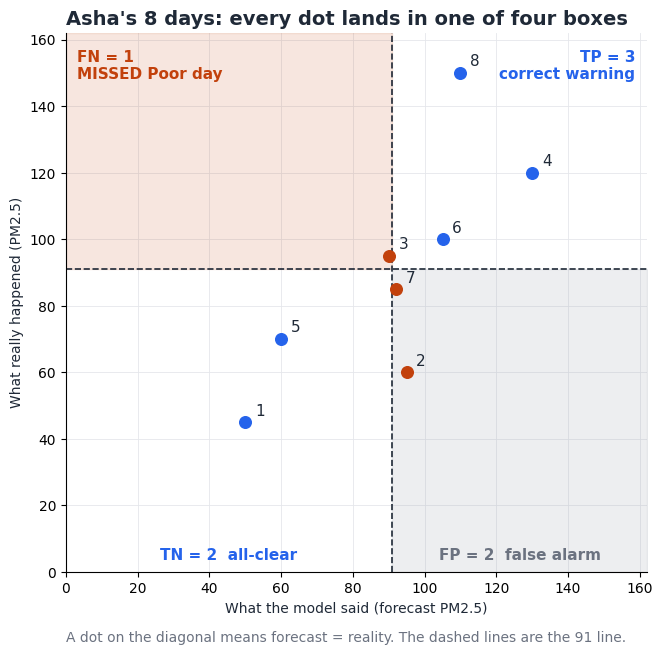

In [3]:
import matplotlib.pyplot as plt

# Same look as the other DAF figures: grey plus one blue accent, orange-red only for problems.
INK, MUTED, GRID = "#1f2937", "#6b7280", "#e5e7eb"
ACCENT, ALERT = "#2563eb", "#c2410c"


def draw_boxes(ax, actual, predicted, line=91, label_days=False):
    """Forecast on the x axis, what really happened on the y axis, one dot per day."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    top = max(actual.max(), predicted.max()) * 1.08

    # Shade the two problem boxes: the dangerous one (missed) and the harmless-but-annoying one.
    ax.fill_between([0, line], line, top, color=ALERT, alpha=0.13)        # FN: said fine, really Poor
    ax.fill_between([line, top], 0, line, color="#9ca3af", alpha=0.18)    # FP: said Poor, really fine
    ax.axvline(line, color=INK, lw=1.2, ls="--")
    ax.axhline(line, color=INK, lw=1.2, ls="--")

    really_poor, warned = actual >= line, predicted >= line
    correct = (really_poor == warned)
    ax.scatter(predicted[correct], actual[correct], s=70, color=ACCENT, zorder=3, label="correct")
    ax.scatter(predicted[~correct], actual[~correct], s=70, color=ALERT, zorder=3, label="mistake")
    if label_days:
        for day, (x, y) in enumerate(zip(predicted, actual), start=1):
            ax.annotate(str(day), (x, y), textcoords="offset points", xytext=(7, 5), fontsize=11, color=INK)

    # Name each box with its count, so the picture and the table say the same thing.
    counts = {
        "TP": int((really_poor & warned).sum()), "FN": int((really_poor & ~warned).sum()),
        "FP": int((~really_poor & warned).sum()), "TN": int((~really_poor & ~warned).sum()),
    }
    ax.text(top * 0.02, top * 0.97, f"FN = {counts['FN']}\nMISSED Poor day", ha="left", va="top", color=ALERT, fontsize=11, fontweight="bold")
    ax.text(top * 0.98, top * 0.97, f"TP = {counts['TP']}\ncorrect warning", ha="right", va="top", color=ACCENT, fontsize=11, fontweight="bold")
    ax.text(line + (top - line) / 2, line * 0.03, f"FP = {counts['FP']}  false alarm", ha="center", va="bottom", color=MUTED, fontsize=11, fontweight="bold")
    ax.text(line * 0.5, line * 0.03, f"TN = {counts['TN']}  all-clear", ha="center", va="bottom", color=ACCENT, fontsize=11, fontweight="bold")
    ax.set_xlim(0, top); ax.set_ylim(0, top)
    ax.set_xlabel("What the model said (forecast PM2.5)", color=INK)
    ax.set_ylabel("What really happened (PM2.5)", color=INK)
    ax.grid(color=GRID, lw=0.6); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


fig, ax = plt.subplots(figsize=(7.5, 7))
draw_boxes(ax, days["actual"], days["forecast"], label_days=True)
ax.set_title("Asha's 8 days: every dot lands in one of four boxes", loc="left", fontsize=14, fontweight="bold", color=INK)
ax.text(0, -0.13, "A dot on the diagonal means forecast = reality. The dashed lines are the 91 line.", transform=ax.transAxes, fontsize=10, color=MUTED)
plt.show()

### Read the picture

Each dot is one day. The **dashed lines** are the 91 line: left of the vertical one the model said "fine", below the horizontal one the day really was fine.

- A dot in the **top-left** box is Day 3, the missed Poor day. It sits only just to the left of the line, so the model was close, but close is not enough when the line decides the action.
- The dots in the **bottom-right** box are the two false alarms, Days 2 and 7.
- Every blue dot is a correct call, on either side. The four box counts add up to 8 days.

Now the same function and the same picture on the real test days.

Persistence on 130 test days: MAE 16.791 | recall 0.471 (8 of 17) | precision 0.400


,Really Poor,Really fine
Model said Poor,8,12
Model said fine,9,101


matches the persistence row from DAF-15 (MAE 16.791, 8 of 17 Poor days caught)


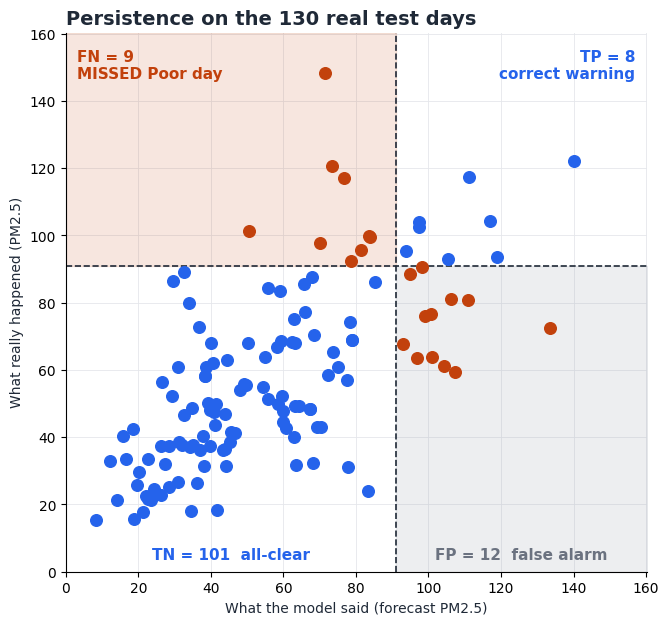

In [4]:
from pathlib import Path

# --- 1. Find the project's data folder (works from the repo root or from the project) ----
project_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "data/interim/daily_17.csv").is_file()
    or (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
)
data_root = (
    project_root / "data"
    if (project_root / "data/interim/daily_17.csv").is_file()
    else project_root / "18_Projects/01_Delhi_Air_Forecast/data"
)

# --- 2. The same daily table and the same 130 test days as DAF-15 -------------------------
daily = pd.read_csv(data_root / "interim/daily_17.csv", parse_dates=["date"], index_col="date")
if daily.index.tz is not None:                               # plain Delhi calendar days, no clock time
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

from delhi_air.clean import add_rolling_features             # our own function from src/delhi_air/clean.py

feature_names = ["pm25_until_17", "mean_3", "mean_7", "mean_14"]   # fixed before any model, as in DAF-15
model_table = add_rolling_features(daily)[feature_names + ["target"]].dropna()
test = model_table.loc[model_table.index >= pd.Timestamp("2026-03-01")]
assert len(test) == 130, "not the same 130 test days as DAF-15"

# --- 3. Persistence: "tomorrow = what today looks like so far" ----------------------------
persistence = score_forecasts(test["target"], test["pm25_until_17"])
print(f"Persistence on {persistence['n_days']} test days: MAE {persistence['mae']:.3f} | "
      f"recall {persistence['recall']:.3f} ({persistence['tp']} of {persistence['n_poor']}) | "
      f"precision {persistence['precision']:.3f}")
display(confusion_table(persistence))

# --- 4. It must match DAF-15's re-scored persistence row, or the function is wrong --------
assert round(persistence["mae"], 3) == 16.791 and persistence["tp"] == 8 and persistence["n_poor"] == 17
print("matches the persistence row from DAF-15 (MAE 16.791, 8 of 17 Poor days caught)")

fig, ax = plt.subplots(figsize=(7.5, 7))
draw_boxes(ax, test["target"], test["pm25_until_17"])
ax.set_title("Persistence on the 130 real test days", loc="left", fontsize=14, fontweight="bold", color=INK)
plt.show()

### Read the result

Persistence warned on 20 days and was right on 8 of them. The function **reproduces DAF-15's persistence numbers exactly** (MAE 16.791, 8 of 17 Poor days caught), so we can trust it before walk-forward relies on it.

What the new view adds, which MAE never showed:

- **Precision 0.40.** Only 8 of the 20 warnings were real. Asha would have cancelled 12 outdoor days for nothing.
- **9 missed Poor days**, the top-left box. Look at where they sit: they run from just over the line (real 92) up to the worst day of the test period (real 148), and every one had a forecast under 91. Persistence only knows today's hours up to 17:00, so it is blind to a day that turns worse overnight.
- **Recall 0.471** is the share of the top row that was caught: 8 of 17.

Not one mistake here is averaged away. That is what Asha asked for.

## Before Step 2

Step 1 gave us the ruler: `score_forecasts` returns MAE, recall, precision and the four counts for any forecasts, and `confusion_table` shows them as a 2x2. It passed two checks: a hand-worked 8-day example, and DAF-15's persistence row.

Step 2 rebuilds the feature table over the whole history and chooses the walk-forward start date. Before we can loop over months, we need to know which months exist and how many Poor days each has.

# Step 2 — The whole table, month by month, and the start date

## 🎬 How we got here

Step 1 gave Asha a ruler, `score_forecasts`. Now she needs something to measure. Walk-forward will test the models one **month** at a time, so before writing any loop she needs to know what each month actually contains.

## 😖 The problem

In DAF-15 the split was one cut date, 2026-03-01, and the test half was spring and summer. The picture of "how many Poor days" was a single number: 17. Walk-forward cuts the year into months, and a month can be nothing like its neighbour. If Asha does not look first, she will meet these surprises **inside** the loop, where they are hard to see:

```text
a month with 0 Poor days    ->  recall = 0 ÷ 0, undefined
a month with 9 usable days  ->  one day moves the score a lot
a start date too early      ->  the first models train on almost nothing
a start date too late       ->  the winter never gets tested
```

## 💡 The idea

Build the feature table **once** for the whole history, count the days and the Poor days in each month, and only then choose the start date.

```text
daily_17.csv
     │  add the 4 features (all look backwards only)
     ▼
model_table: one row per usable day, 381 rows
     │  group by month
     ▼
days and Poor days per month  ──►  choose the start date
                                   everything before it  = first training window
                                   every month from it   = one monthly exam
```

Backend analogy: before replaying last year's traffic against a system, you look at the traffic first. You check for empty hours, for the week the logging broke, and for the peak, and then you choose where the replay starts.

## 🔍 What this actually is

- **Same 4 features as DAF-15:** `pm25_until_17`, `mean_3`, `mean_7`, `mean_14`. They were fixed before any model was fitted, and they stay fixed.
- **Is building features once a leak?** The ticket warns about "a feature computed once on all rows before looping". That is only a leak when a feature looks at the **future**, for example a scaler fitted on all rows. Our rolling means use yesterday and earlier. A row's value is the same whether we build the table once or rebuild it on the day. The second code cell **proves** this on real dates instead of just claiming it.
- **The start date is a choice.** It is a constant at the top of the cell, so it is easy to change. We choose it with the numbers in front of us.

### 🤔 Before you run the code

The data has one winter, and the test half in DAF-15 held only 17 Poor days out of 130. Predict: how many Poor days do you expect in November and December? Then read the table.

In [5]:
# Continues from Step 1: daily, model_table, feature_names, score_forecasts.

# --- 1. Two settings for this ticket, written down before any model runs ---------------
poor_line = 91                           # PM2.5 at or above this is a Poor day (CPCB, D-001)
walk_start = pd.Timestamp("2025-10-01")  # first month to be tested; everything before it is the first training window

# --- 2. Count days and Poor days in each calendar month ----------------------------------
table = model_table.assign(poor=model_table["target"] >= poor_line)   # True on a really Poor day
month = table.index.to_period("M")                                    # "2025-10", "2025-11", ...
by_month = table.groupby(month).agg(
    days=("target", "size"),             # usable days in the month
    poor_days=("poor", "sum"),           # how many of them were really Poor
    mean_pm25=("target", "mean"),        # how bad the month was on average
)
by_month["share_poor"] = by_month["poor_days"] / by_month["days"]
# Mark each month: "train only" lies wholly before the start date, "tested" is scored by walk-forward.
by_month["role"] = np.where(by_month.index.to_timestamp() < walk_start, "train only", "tested")
display(by_month.round({"mean_pm25": 1, "share_poor": 2}))

# --- 3. What the first model will see, and what the loop will test ---------------------------
first_train = table.loc[table.index < walk_start]
tested = table.loc[table.index >= walk_start]
print(f"first training window: {len(first_train)} days, {int(first_train['poor'].sum())} Poor "
      f"({first_train.index.min().date()} to {first_train.index.max().date()})")
print(f"tested by the loop:    {len(tested)} days, {int(tested['poor'].sum())} Poor, "
      f"in {tested.index.to_period('M').nunique()} monthly exams")
no_poor = by_month.index[(by_month["role"] == "tested") & (by_month["poor_days"] == 0)]
print("tested months with 0 Poor days (recall will be undefined):", ", ".join(str(m) for m in no_poor))

# --- 4. Safety checks: stop loudly if the table is not the one DAF-15 used -------------------
assert len(table) == 381 and int(table["poor"].sum()) == 134, "table differs from DAF-15's 251 + 130 rows"

,days,poor_days,mean_pm25,share_poor,role
date,,,,,
2025-03,14,4,77.2,0.29,train only
2025-04,8,4,96.5,0.50,train only
2025-05,15,2,73.3,0.13,train only
2025-06,13,1,61.0,0.08,train only
2025-07,26,3,54.9,0.12,train only
2025-08,29,0,40.7,0.00,train only
2025-09,30,0,41.8,0.00,train only
2025-10,29,18,142.7,0.62,tested
2025-11,29,29,238.8,1.00,tested


first training window: 135 days, 14 Poor (2025-03-17 to 2025-09-30)
tested by the loop:    246 days, 120 Poor, in 11 monthly exams
tested months with 0 Poor days (recall will be undefined): 2026-06, 2026-07, 2026-08


### Read the result

| | Days | Poor days | Share Poor |
|---|---:|---:|---:|
| First training window (Mar to Sep 2025) | 135 | 14 | 10% |
| Tested by the loop (Oct 2025 to Aug 2026) | 246 | 120 | 49% |

Four things stand out:

- **November and December are all Poor.** 29 of 29 usable days in each. In those two months there is no fine day at all, so there can be no false alarm, and the only thing left to judge is recall. January is 9 of 9 for the same reason.
- **The first model has never seen a winter.** Its 135 training days hold only 14 Poor days, and its single worst day is 251. A typical December day averages 247 and the worst reaches 458, so it has met one bad day but never a whole month of them. This is the hard, honest test. A model that has only seen the monsoon is asked about the smog. Expect it to under-predict at first, and expect the random forest to be the most stuck, because a forest cannot predict higher than the highest target it was trained on.
- **Three tested months have no Poor days** (June, July and August 2026). Their recall is undefined, and `score_forecasts` returns `NaN` for them, which is exactly why Step 1 was written that way. Their MAE and false alarms still count.
- **January has 9 usable days and August 7.** The sensor was down from 10 to 19 January, and `mean_14` needs 14 clean days in a row, so about a month of rows is lost. August has 7 because the sensor again has missing days (11 of them) and the same 14-day rule costs more rows. Monthly scores on 7 to 9 days are noisy, so we read them with the day counts beside them.

In [6]:
# --- Prove that building the features once does not leak the future -------------------------
# For a few real dates, pretend today IS that date: throw away every later day, rebuild the
# features from what is left, and compare with the value from the full table.
rolling_columns = ["mean_3", "mean_7", "mean_14"]
full_features = add_rolling_features(daily)               # built once, on every row

rows = []
for date in ["2025-06-09", "2025-10-16", "2025-12-15", "2026-03-16"]:
    assert pd.Timestamp(date) in model_table.index, f"{date} is not a usable day"
    only_the_past = daily.loc[:date]                       # nothing after `date` exists
    rebuilt = add_rolling_features(only_the_past).loc[date, rolling_columns].astype(float)   # .astype: the table mixes bool and float columns
    from_full = full_features.loc[date, rolling_columns].astype(float)
    rows.append({"date": date, **{f"{c} (full)": from_full[c] for c in rolling_columns},
                 "identical": bool(np.allclose(rebuilt, from_full))})
    assert np.allclose(rebuilt, from_full), f"features at {date} depend on later rows"

display(pd.DataFrame(rows).set_index("date").round(2))
print("every feature is identical when the future is removed, so one build is safe")

,mean_3 (full),mean_7 (full),mean_14 (full),identical
date,,,,
2025-06-09,77.20,60.66,61.66,True
2025-10-16,95.37,82.38,68.24,True
2025-12-15,365.38,251.78,235.94,True
2026-03-16,77.42,97.43,98.63,True


every feature is identical when the future is removed, so one build is safe


### Read the result

All four dates give identical features whether the future is present or not. A rolling mean over yesterday and earlier **cannot** know about tomorrow, so building the table once and slicing it by date is safe.

This is **not** true for everything. The scaler and the feature selector in the Ridge pipeline learn from the data, so they must be fitted again inside every step of the loop, on that step's training days only. That is Rule 1 from the top of the notebook, and the loop in Step 3 will do exactly that.

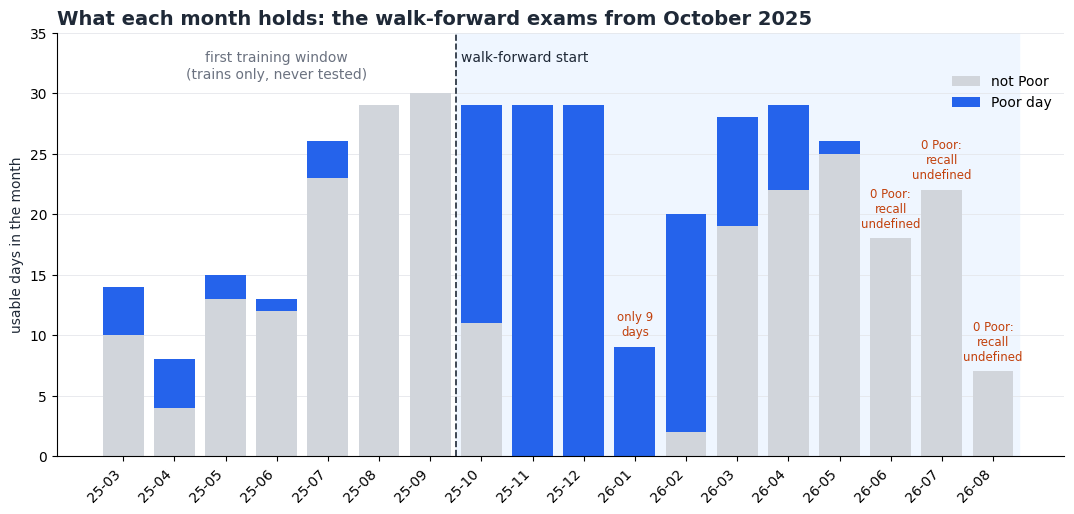

In [7]:
import matplotlib.pyplot as plt

# Same palette as Step 1: grey plus one blue accent, orange-red only for a problem with a text label.
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(by_month))
tested_mask = (by_month["role"] == "tested").to_numpy()

# Each bar is one month. Grey = days that were not Poor, blue = Poor days.
ax.bar(x, by_month["days"] - by_month["poor_days"], color="#d1d5db", label="not Poor")
ax.bar(x, by_month["poor_days"], bottom=by_month["days"] - by_month["poor_days"], color=ACCENT, label="Poor day")

# Shade the months the loop will test, and label the start date.
first_test = int(np.argmax(tested_mask))
ax.axvspan(first_test - 0.5, len(x) - 0.5, color="#eff6ff", zorder=0)
ax.axvline(first_test - 0.5, color=INK, ls="--", lw=1.2)
ax.text(first_test - 0.4, 33.5, "walk-forward start", color=INK, fontsize=10, va="top")
ax.text(first_test / 2 - 0.5, 33.5, "first training window\n(trains only, never tested)", ha="center", va="top", color=MUTED, fontsize=10)

# Label the months where a score will be shaky, so nobody over-reads them.
for i, (name, row) in enumerate(by_month.iterrows()):
    if tested_mask[i] and row["poor_days"] == 0:
        ax.text(i, row["days"] + 0.7, "0 Poor:\nrecall\nundefined", ha="center", va="bottom", fontsize=8.5, color=ALERT)
    elif tested_mask[i] and row["days"] < 12:
        ax.text(i, row["days"] + 0.7, f"only {int(row['days'])}\ndays", ha="center", va="bottom", fontsize=8.5, color=ALERT)

ax.set_xticks(x)
ax.set_xticklabels([str(m)[2:] for m in by_month.index], rotation=45, ha="right")
ax.set_ylim(0, 35)
ax.set_ylabel("usable days in the month", color=INK)
ax.set_title("What each month holds: the walk-forward exams from October 2025", loc="left", fontsize=14, fontweight="bold", color=INK)
ax.grid(axis="y", color=GRID, lw=0.6); ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.93))
plt.show()

### Read the picture

Grey and blue together are the usable days in a month, and the blue part is the Poor days. Read it from left to right and you can watch Delhi's year: almost no blue through the monsoon, a sudden jump in October, a solid wall of blue in November and December, and a slow fade to nothing by June.

The dashed line is the walk-forward start, **1 October 2025**.

### Why 1 October, and what we gave up

| Start date | First training window | Tested months | The catch |
|---|---|---|---|
| 1 September | 105 days, 14 Poor | 12 | Adds September, which has 0 Poor days: nothing to score, and the first model trains on less |
| **1 October (chosen)** | **135 days, 14 Poor** | **11** | The smog arrives in the first exam, so we see how a model without any winter experience copes |
| 1 November | 164 days, 32 Poor | 10 | Drops October, the month the air turns. The most useful early-warning month is never tested |

October gives the first model seven months to learn from and still tests the whole winter. We lose nothing the ticket asked for, and every later change of the date is one line (`walk_start`).

## Before Step 3

Step 2 told us what the exams contain: 11 monthly exams, 246 days, 120 Poor, three months where recall is undefined and two with fewer than 10 days.

Step 3 writes the walk-forward loop: for each month from October, fit on every earlier day, predict that month, and keep the forecasts. It is the heart of the ticket, so we will write it carefully and test it before we trust it.